This project analyzes the Pima Indians Diabetes Dataset to build and evaluate binary classification models for predicting diabetes. The workflow includes data quality assessment, exploratory data analysis (EDA), model training, evaluation, and performance improvement through feature selection and class balancing. Two models are compared: Logistic Regression and Random Forest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, classification_report, roc_auc_score
)

In [2]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
df.head()

Mounted at /content/drive


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


The dataset contains 768 observations and 8 predictor variables along with the binary outcome. Although there are no formally missing values, several variables contain zero values, which are not physiologically valid (e.g., Glucose and BMI). These zeros are treated as missing data and need to be handled appropriately before modeling.

In [4]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
for col in cols_with_zero:
    df_clean = df_clean[df_clean[col] != 0]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (768, 9)
Cleaned shape: (392, 9)


Rows containing zero values in key medical variables were removed to ensure that only valid physiological observations are used. The dataset reduces from 768 to approximately 392 rows, indicating that nearly half of the data contained invalid entries. While this improves data quality, it reduces sample size, which may affect model generalizability.

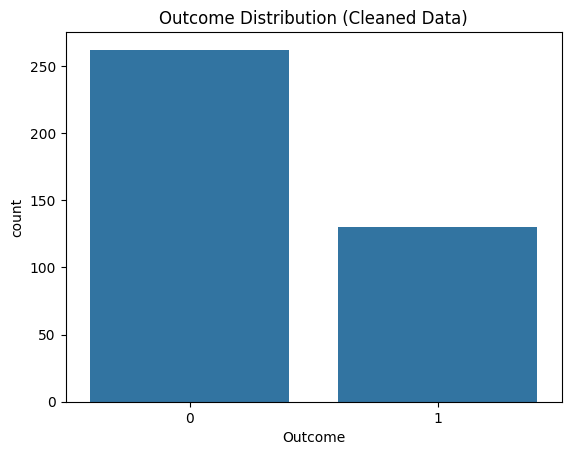

In [5]:
sns.countplot(x='Outcome', data=df_clean)
plt.title("Outcome Distribution (Cleaned Data)")
plt.show()

A count plot was used to visualize class distribution because it clearly shows the balance between diabetic and non-diabetic cases. The dataset remains moderately imbalanced after cleaning, with more non-diabetic cases than diabetic ones. This imbalance can influence model performance, particularly recall for the minority class.

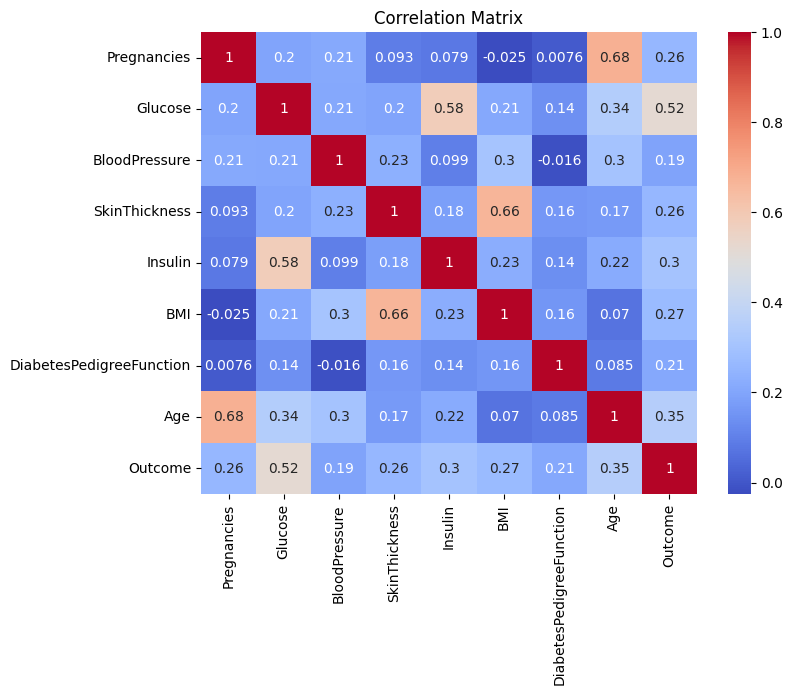

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The heatmap was selected because it provides a comprehensive view of relationships between all variables simultaneously. The plot shows that Glucose has the strongest correlation with diabetes outcome (~0.52), followed by BMI, Age, and Pregnancies. This supports their selection as key predictive features

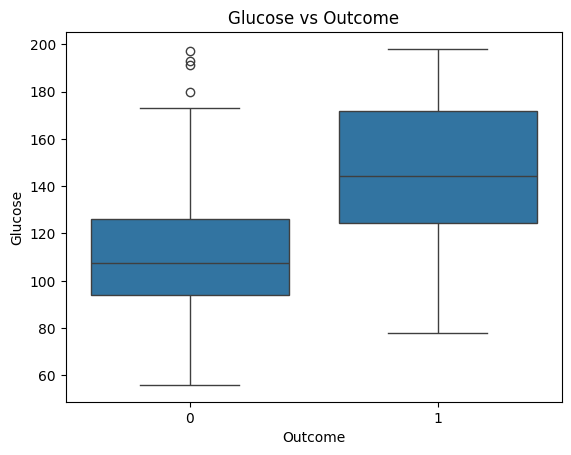

In [17]:
sns.boxplot(x='Outcome', y='Glucose', data=df_clean)
plt.title("Glucose vs Outcome")
plt.show()

A boxplot was selected to compare the distribution of glucose levels between diabetic and non-diabetic groups. This type of plot is effective for visualizing differences in median, spread, and outliers. The plot shows that glucose levels are generally higher among diabetic individuals, reinforcing its importance as a key predictor of diabetes.

In [7]:
selected_features = ['Glucose', 'BMI', 'Age', 'Pregnancies']

X = df_clean[selected_features]
y = df_clean['Outcome']

Features were selected based on both correlation analysis and domain knowledge. Variables such as Glucose (0.52 correlation), BMI (0.27), Age (0.35), and Pregnancies (0.26) showed relatively stronger relationships with the target variable in the correlation matrix. These features are also clinically relevant indicators of diabetes risk, making them suitable for inclusion in the model while reducing noise from less informative variables.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

The dataset was split into training (80%) and testing (20%) sets to evaluate model performance on unseen data. Stratification was used to preserve class distribution in both sets, ensuring a fair evaluation despite class imbalance.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [11]:
print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Performance:
Accuracy: 0.8354430379746836
Precision: 0.76
Recall: 0.7307692307692307
F1 Score: 0.7450980392156863
ROC-AUC: 0.8759071117561684


The baseline Logistic Regression model achieved an accuracy of 0.8354, indicating strong predictive performance. Precision (0.76) and recall (0.73) suggest that the model performs well in identifying diabetic cases while maintaining reasonable correctness. However, some diabetic cases are still missed, indicating room for improvement

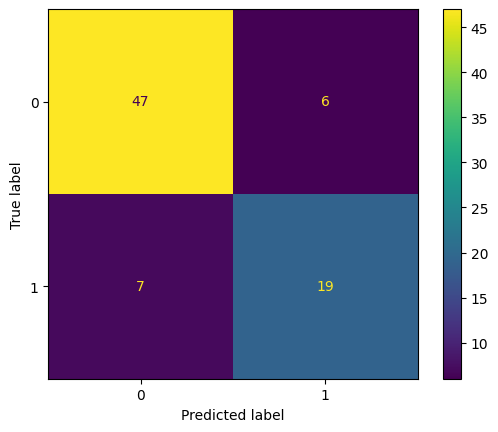

In [12]:
ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.show()

The confusion matrix shows that most predictions are correct, with relatively few false positives and false negatives. However, false negatives remain important, as they represent diabetic patients who are not identified by the model.

The baseline model can be improved by addressing class imbalance using class weighting, which increases the importance of correctly predicting diabetic cases. Additionally, alternative models such as Random Forest can capture non-linear relationships between features that Logistic Regression may not fully model. These approaches aim to improve recall and overall model robustness.

In [13]:
lr_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_bal.fit(X_train_scaled, y_train)

y_pred_lr_bal = lr_bal.predict(X_test_scaled)
y_prob_lr_bal = lr_bal.predict_proba(X_test_scaled)[:,1]

In [14]:
print("Balanced Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_bal))
print("Precision:", precision_score(y_test, y_pred_lr_bal))
print("Recall:", recall_score(y_test, y_pred_lr_bal))
print("F1 Score:", f1_score(y_test, y_pred_lr_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr_bal))

Balanced Logistic Regression Performance:
Accuracy: 0.810126582278481
Precision: 0.6774193548387096
Recall: 0.8076923076923077
F1 Score: 0.7368421052631579
ROC-AUC: 0.876632801161103


Compared to the baseline Logistic Regression model, the balanced model improved recall from 0.73 to 0.81, indicating better detection of diabetic cases. This improvement comes with a slight decrease in precision, highlighting the trade-off between identifying more true cases and increasing false positives. In a medical context, this trade-off is acceptable because missing true diabetic cases is more critical.

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [16]:
print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Performance:
Accuracy: 0.810126582278481
Precision: 0.7037037037037037
Recall: 0.7307692307692307
F1 Score: 0.7169811320754716
ROC-AUC: 0.865021770682148


Although Random Forest captures non-linear relationships and achieved strong overall performance, its recall (0.73) is lower than that of Balanced Logistic Regression (0.81). This indicates that it misses more diabetic cases, making it less suitable for medical screening tasks where minimizing false negatives is critical.

**FINAL COMPARISON**

The baseline Logistic Regression model provided strong overall accuracy, while Balanced Logistic Regression improved recall significantly by addressing class imbalance. Random Forest performed well but did not surpass Balanced Logistic Regression in identifying diabetic cases. Therefore, Balanced Logistic Regression is the most suitable model for this task, as it minimizes false negatives and improves detection of diabetic patients.

**CONCLUSION**

Removing rows with invalid zero values improved model performance by ensuring that only physiologically valid data was used. However, this approach reduced the dataset size by nearly 50%, which may affect the model’s ability to generalize to new data. This highlights an important trade-off in machine learning between data quality and data quantity. Logistic Regression performed well as a baseline model, while class balancing significantly improved recall. Random Forest provided comparable performance but did not offer a clear advantage. Overall, Balanced Logistic Regression is preferred for medical screening tasks due to its higher sensitivity in detecting diabetic cases.